## Import libraries

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')


project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)


# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 150

In [2]:
from IPython.display import Image

from fmu2ml.analysis.multivariate_effect_analysis.analyzers import (
    PartialCorrelationAnalyzer,
    MultipleRegressionAnalyzer,
    LaggedEffectAnalyzer,
    AutocorrelationAnalyzer
)
from fmu2ml.analysis.multivariate_effect_analysis.visualizers import *
from fmu2ml.analysis.input_output_relations.analyzers import DataGenerator
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
num_cdus = config['NUM_CDUS']

In [4]:
# Configuration
TOTAL_TIMESTEPS = 7200
SAMPLES_PER_HOUR = 60
MAX_LAG = 30
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/multivariate_effect'
DATA_DIR = f'../results/{SYSTEM_NAME}/data_analysis/multivariate_effect'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input ranges
INPUT_RANGES = {
    'Q_flow': (12.0, 40.0),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '128GB'
KEY_OUTPUTS = ['T_prim_r_C', 'W_flow_CDUP_kW', 'V_flow_prim_GPM']

print(f"System: {SYSTEM_NAME}")
print(f"Total timesteps: {TOTAL_TIMESTEPS}")
print(f"Workers: {N_WORKERS}")
print(f"Max lag: {MAX_LAG}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Number of CDUs: {num_cdus}")
print(f"Configuration loaded for {SYSTEM_NAME}")



System: summit
Total timesteps: 7200
Workers: 48
Max lag: 30
Output dir: ../results/summit/data_analysis/multivariate_effect
Number of CDUs: 257
Configuration loaded for summit


In [5]:
# Generate or Load Data
data_generator = DataGenerator(
    n_workers=N_WORKERS,
    **config
)
data_file = os.path.join(OUTPUT_DIR, 'sensitivity_data.parquet')

data = None
if os.path.exists(data_file):
    print("Importing the previously generated data")
    data = pd.read_parquet(data_file)
else:
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    # Save data
    data.to_parquet(data_file)
    print(f"Data saved to: {data_file}")

print(f"Data shape: {data.shape}")
print(f"\nColumns: {list(data.columns[:10])}...")




2026-02-06 07:44:50 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: summit
2026-02-06 07:44:50 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 257


Importing the previously generated data
Data shape: (60000, 1105)

Columns: ['simulator[1].datacenter[1].summary.m_flow_prim', 'simulator[1].datacenter[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C']...


## 1. Partial Correlation Analysis

In [8]:

# Partial Correlation Analysis - Setup
partial_analyzer = PartialCorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    significance_threshold=0.05,
    edge_threshold=0.1,
    method='pearson'
)

prepared_data = partial_analyzer.prepare_data(data)


2026-01-30 07:19:31 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - PartialCorrelationAnalyzer initialized for system: summit
2026-01-30 07:19:31 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Method: pearson, Significance threshold: 0.05
2026-01-30 07:19:31 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Preparing data for partial correlation analysis...
2026-01-30 07:19:31 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


In [9]:

# Partial Correlation Analysis - Compute
print("Computing partial correlations...")
partial_df = partial_analyzer.analyze_partial_correlations(prepared_data)

print(f"\nTotal relationships analyzed: {len(partial_df)}")
print(f"Direct effects identified: {partial_df['is_direct_effect'].sum()}")


2026-01-30 07:19:39 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-30 07:19:39 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Initializing Dask cluster for partial correlation analysis...
2026-01-30 07:19:39 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-01-30 07:19:39 - distributed.scheduler - INFO - State start
2026-01-30 07:19:39 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-comh8k91', purging
2026-01-30 07:19:39 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:34859
2026-01-30 07:19:39 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-01-30 07:19:39 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Computing partial correlations...


2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36733'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44621'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34563'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33783'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36855'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40325'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40619'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36259'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45401'
2026-01-30 07:19:39 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42723'
2026-01-30 07:19:39 - distribu


Total relationships analyzed: 36
Direct effects identified: 5


2026-01-30 07:36:43 - distributed.scheduler - INFO - Remove client Client-f4276588-fdd5-11f0-8357-0a580a221f99
2026-01-30 07:36:43 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:40918; closing.
2026-01-30 07:36:43 - distributed.scheduler - INFO - Remove client Client-f4276588-fdd5-11f0-8357-0a580a221f99
2026-01-30 07:36:44 - distributed.scheduler - INFO - Close client connection: Client-f4276588-fdd5-11f0-8357-0a580a221f99


In [10]:

# Display top direct effects
direct_effects = partial_df[partial_df['is_direct_effect']].copy()
direct_effects['abs_partial'] = direct_effects['partial_corr'].abs()
top_direct = direct_effects.nlargest(10, 'abs_partial')

print("\nTop 10 Direct Effects:")
print(top_direct[['input', 'output', 'pearson_corr', 'partial_corr', ]])



Top 10 Direct Effects:
     input          output  pearson_corr  partial_corr
11  Q_flow             pue     -0.964135     -0.964199
10  Q_flow    p_sec_r_psig      0.729299      0.730241
9   Q_flow    p_sec_s_psig      0.729298      0.730240
1   Q_flow  V_flow_sec_GPM      0.585580      0.586230
27   T_ext      T_prim_s_C      0.100324      0.100049


In [11]:

# Partial Correlation - Visualizations
comparison_data = partial_analyzer.compute_correlation_comparison(prepared_data)
network_data = partial_analyzer.build_network_data(comparison_data['full_results'])

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'partial_correlation')
os.makedirs(viz_dir, exist_ok=True)

create_correlation_comparison_chart(partial_df, viz_dir)
create_correlation_heatmaps(comparison_data, viz_dir)
create_network_diagram(network_data, viz_dir, layout='spring')
create_confounding_analysis_plot(partial_df, viz_dir)




2026-01-30 07:19:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing correlation comparison matrices...
2026-01-30 07:19:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-30 07:19:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Executing 36 partial correlation analyses...
2026-01-30 07:19:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computed 36 partial correlations
2026-01-30 07:19:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Building network diagram data...
2026-01-30 07:19:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Network: 15 nodes, 5 significant edges
2026-01-30 07:19:57 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.pa

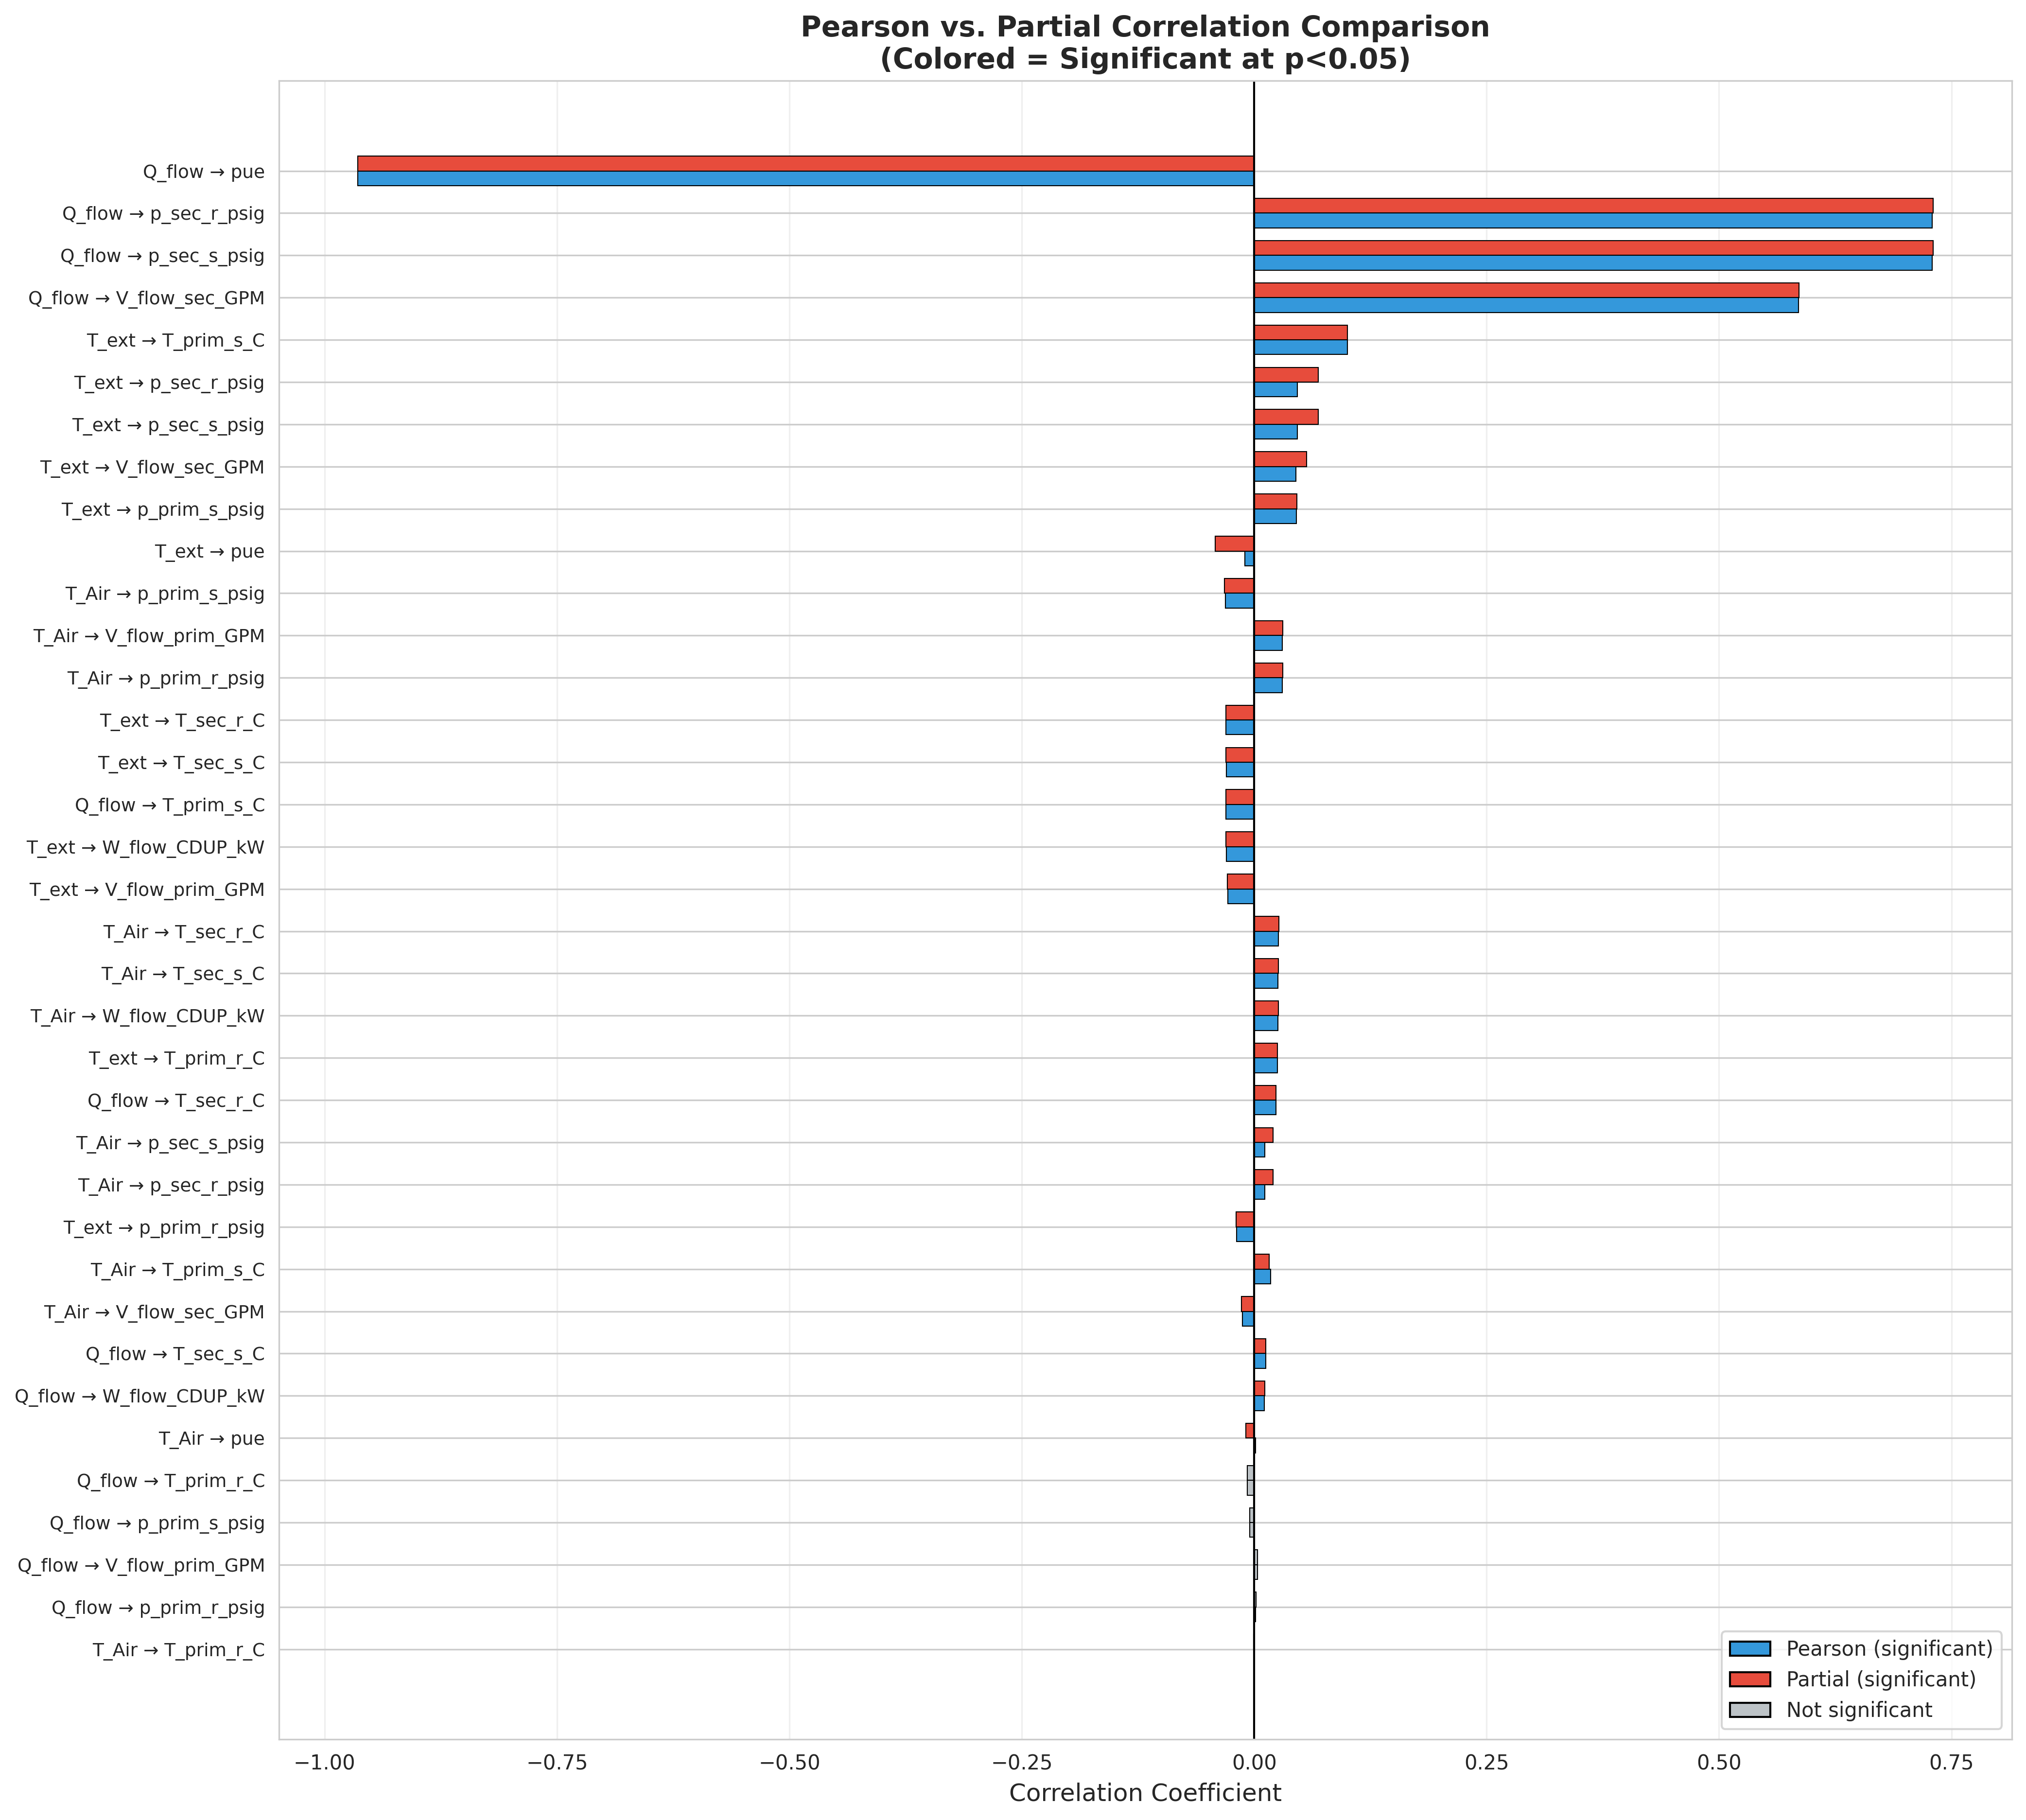

In [5]:
Image(filename=os.path.join(viz_dir, 'correlation_comparison.png'))


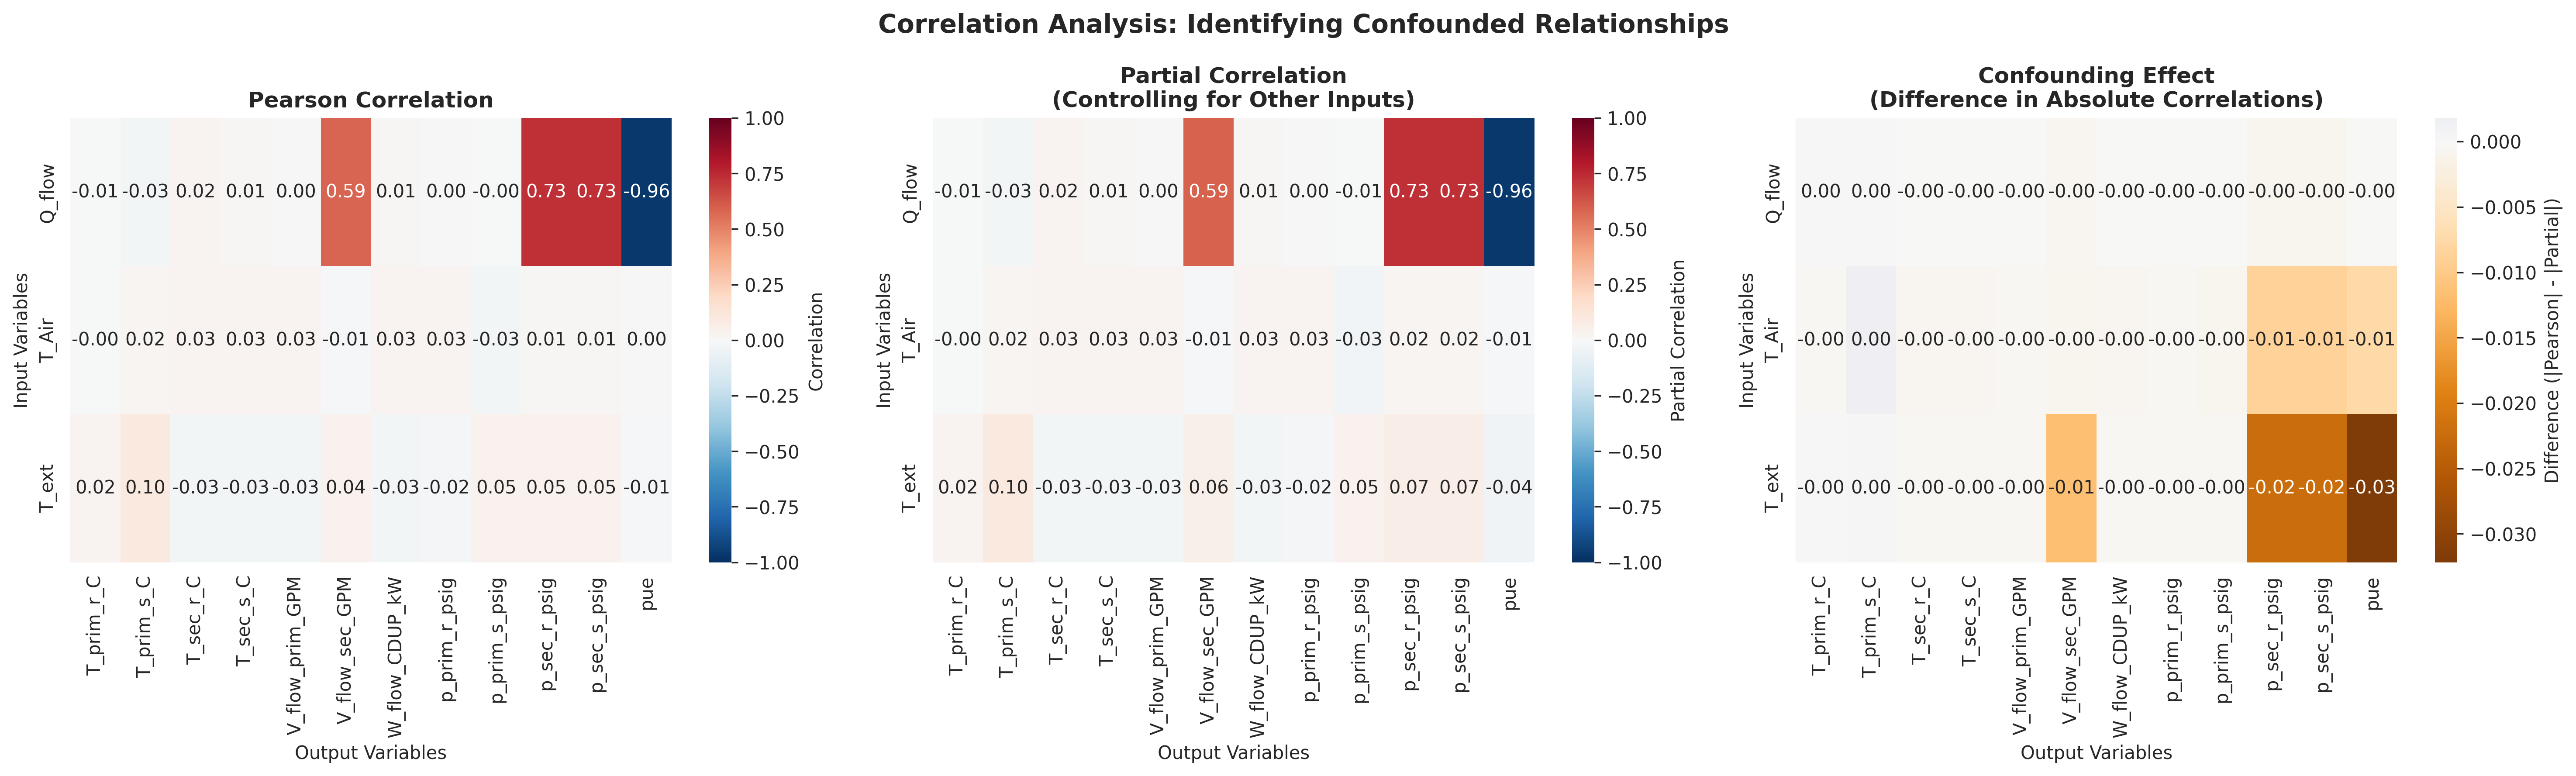

In [6]:
Image(filename=os.path.join(viz_dir, 'correlation_heatmaps.png'))


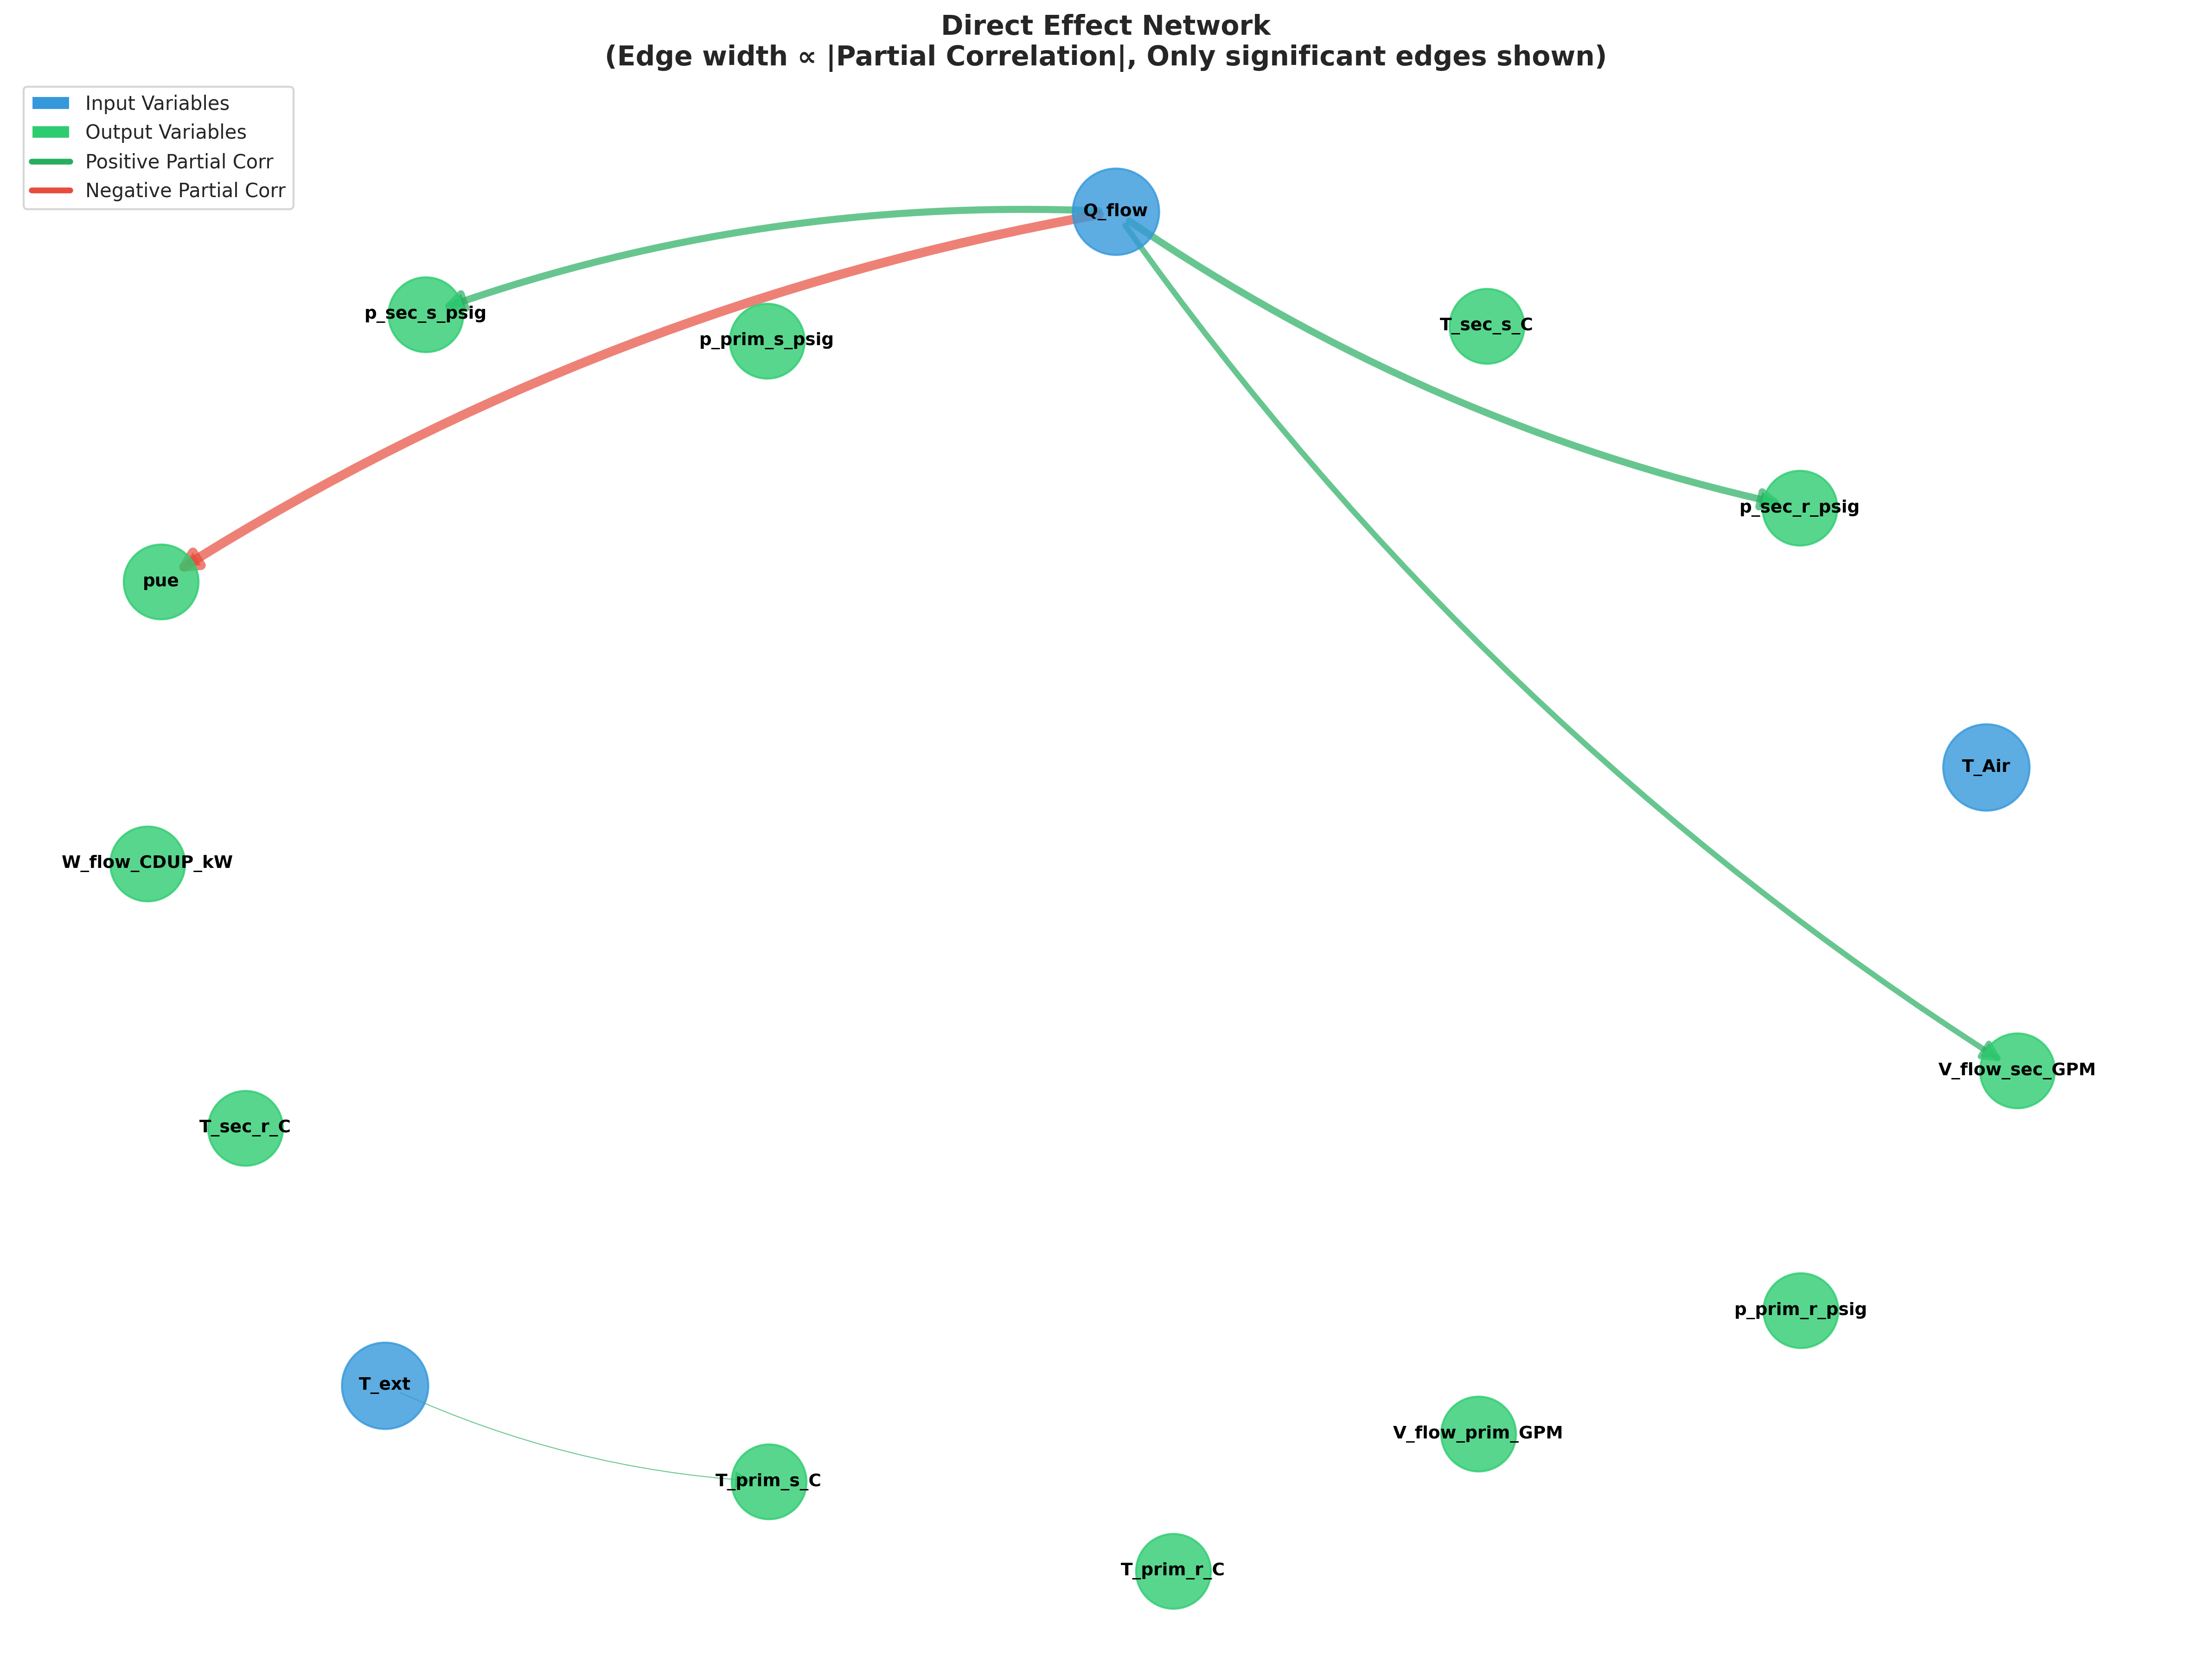

In [15]:
Image(filename=os.path.join(viz_dir, 'direct_effect_network.png'))


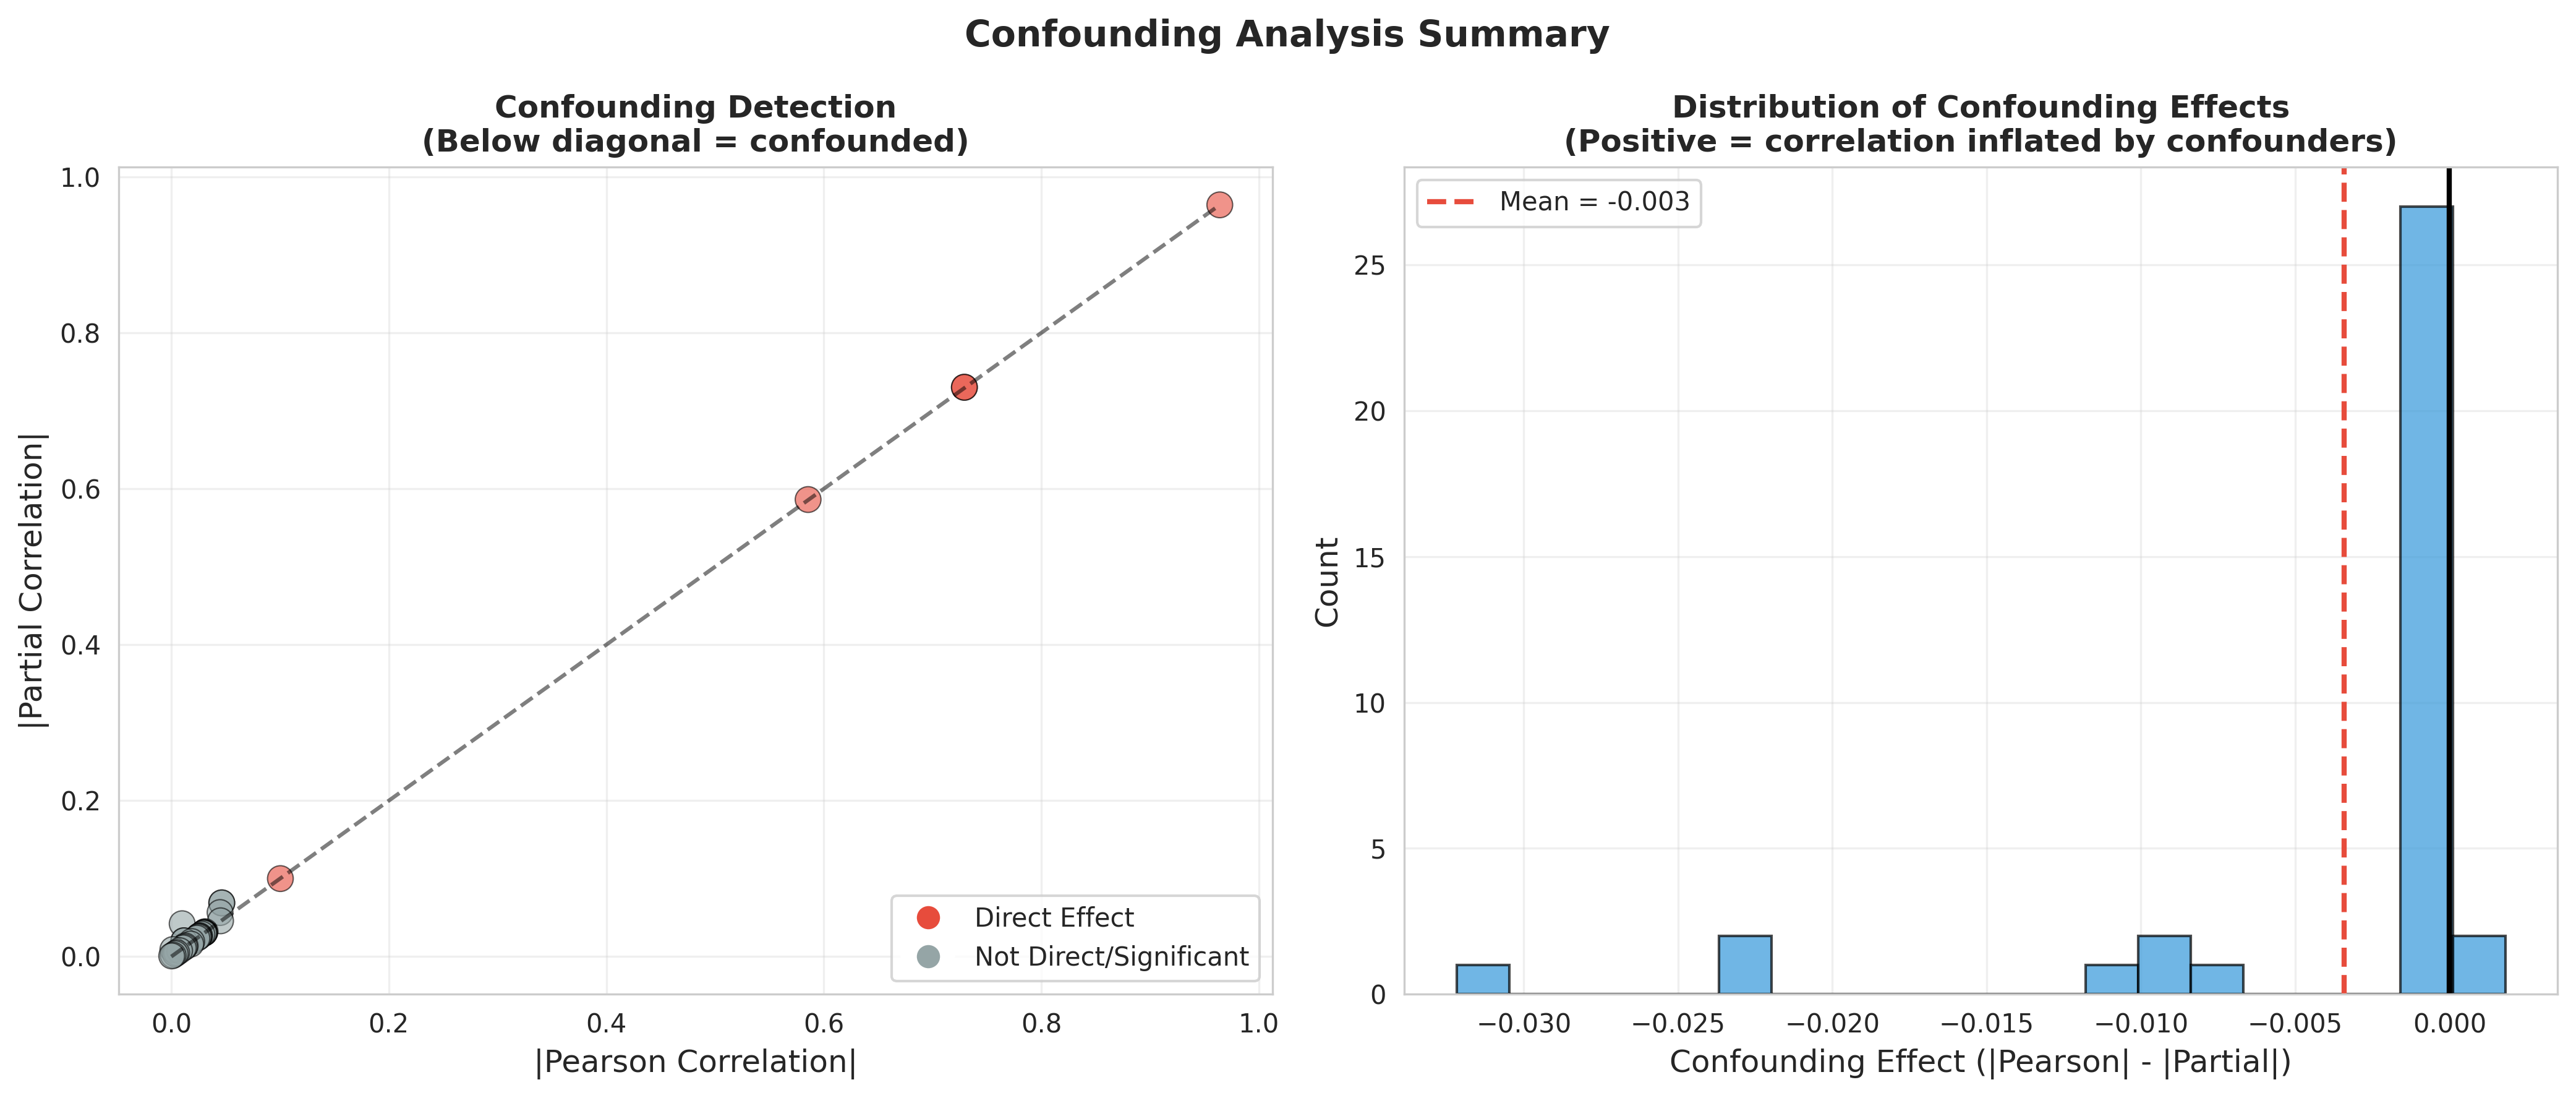

In [14]:
Image(filename=os.path.join(viz_dir, 'confounding_analysis.png'))


### Comparative Visualization

In [19]:

def load_data(file_paths):
    """
    Load CSV files for each system.
    
    Parameters:
    -----------
    file_paths : dict
        Dictionary with system names as keys and file paths as values
        e.g., {'Marconi100': 'path/to/marconi.csv', 'Summit': 'path/to/summit.csv', ...}
    
    Returns:
    --------
    dict : Dictionary of DataFrames
    """
    data = {}
    for system, path in file_paths.items():
        df = pd.read_csv(path)
        df['system'] = system
        df['input_output'] = df['input'] + ' → ' + df['output']
        data[system] = df
    return data


def plot_top_relationships_radar(data, figsize=(12, 10), save_path=None):
    """
    Radar chart comparing top relationships across systems.
    """
    df_all = pd.concat(data.values(), ignore_index=True)
    
    # Get top 8 relationships
    avg_corr = df_all.groupby('input_output')['partial_corr'].apply(lambda x: np.mean(np.abs(x)))
    top_pairs = avg_corr.nlargest(8).index.tolist()
    
    systems = list(data.keys())
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    # Number of variables
    N = len(top_pairs)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    
    for system, color in zip(systems, colors):
        df = data[system].set_index('input_output')
        values = [abs(df.loc[pair, 'partial_corr']) if pair in df.index else 0 
                  for pair in top_pairs]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=system, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(top_pairs, size=8)
    ax.set_ylim(0, 1)
    ax.set_title('Top Relationships Comparison\n(|Partial Correlation|)', size=12, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    if save_path:
         fig.savefig(f"{save_path}/radar_summary.png", dpi=300, bbox_inches='tight')
    return fig






In [20]:
# file paths
file_paths = {
    'Marconi100': '../results/marconi100/data_analysis/multivariate_effect/partial_correlations.csv',
    'Summit': '../results/summit/data_analysis/multivariate_effect/partial_correlations.csv',
    'Lassen': '../results/lassen/data_analysis/multivariate_effect/partial_correlations.csv'
}

data = load_data(file_paths)

# Combine all data
df_all = pd.concat(data.values(), ignore_index=True)


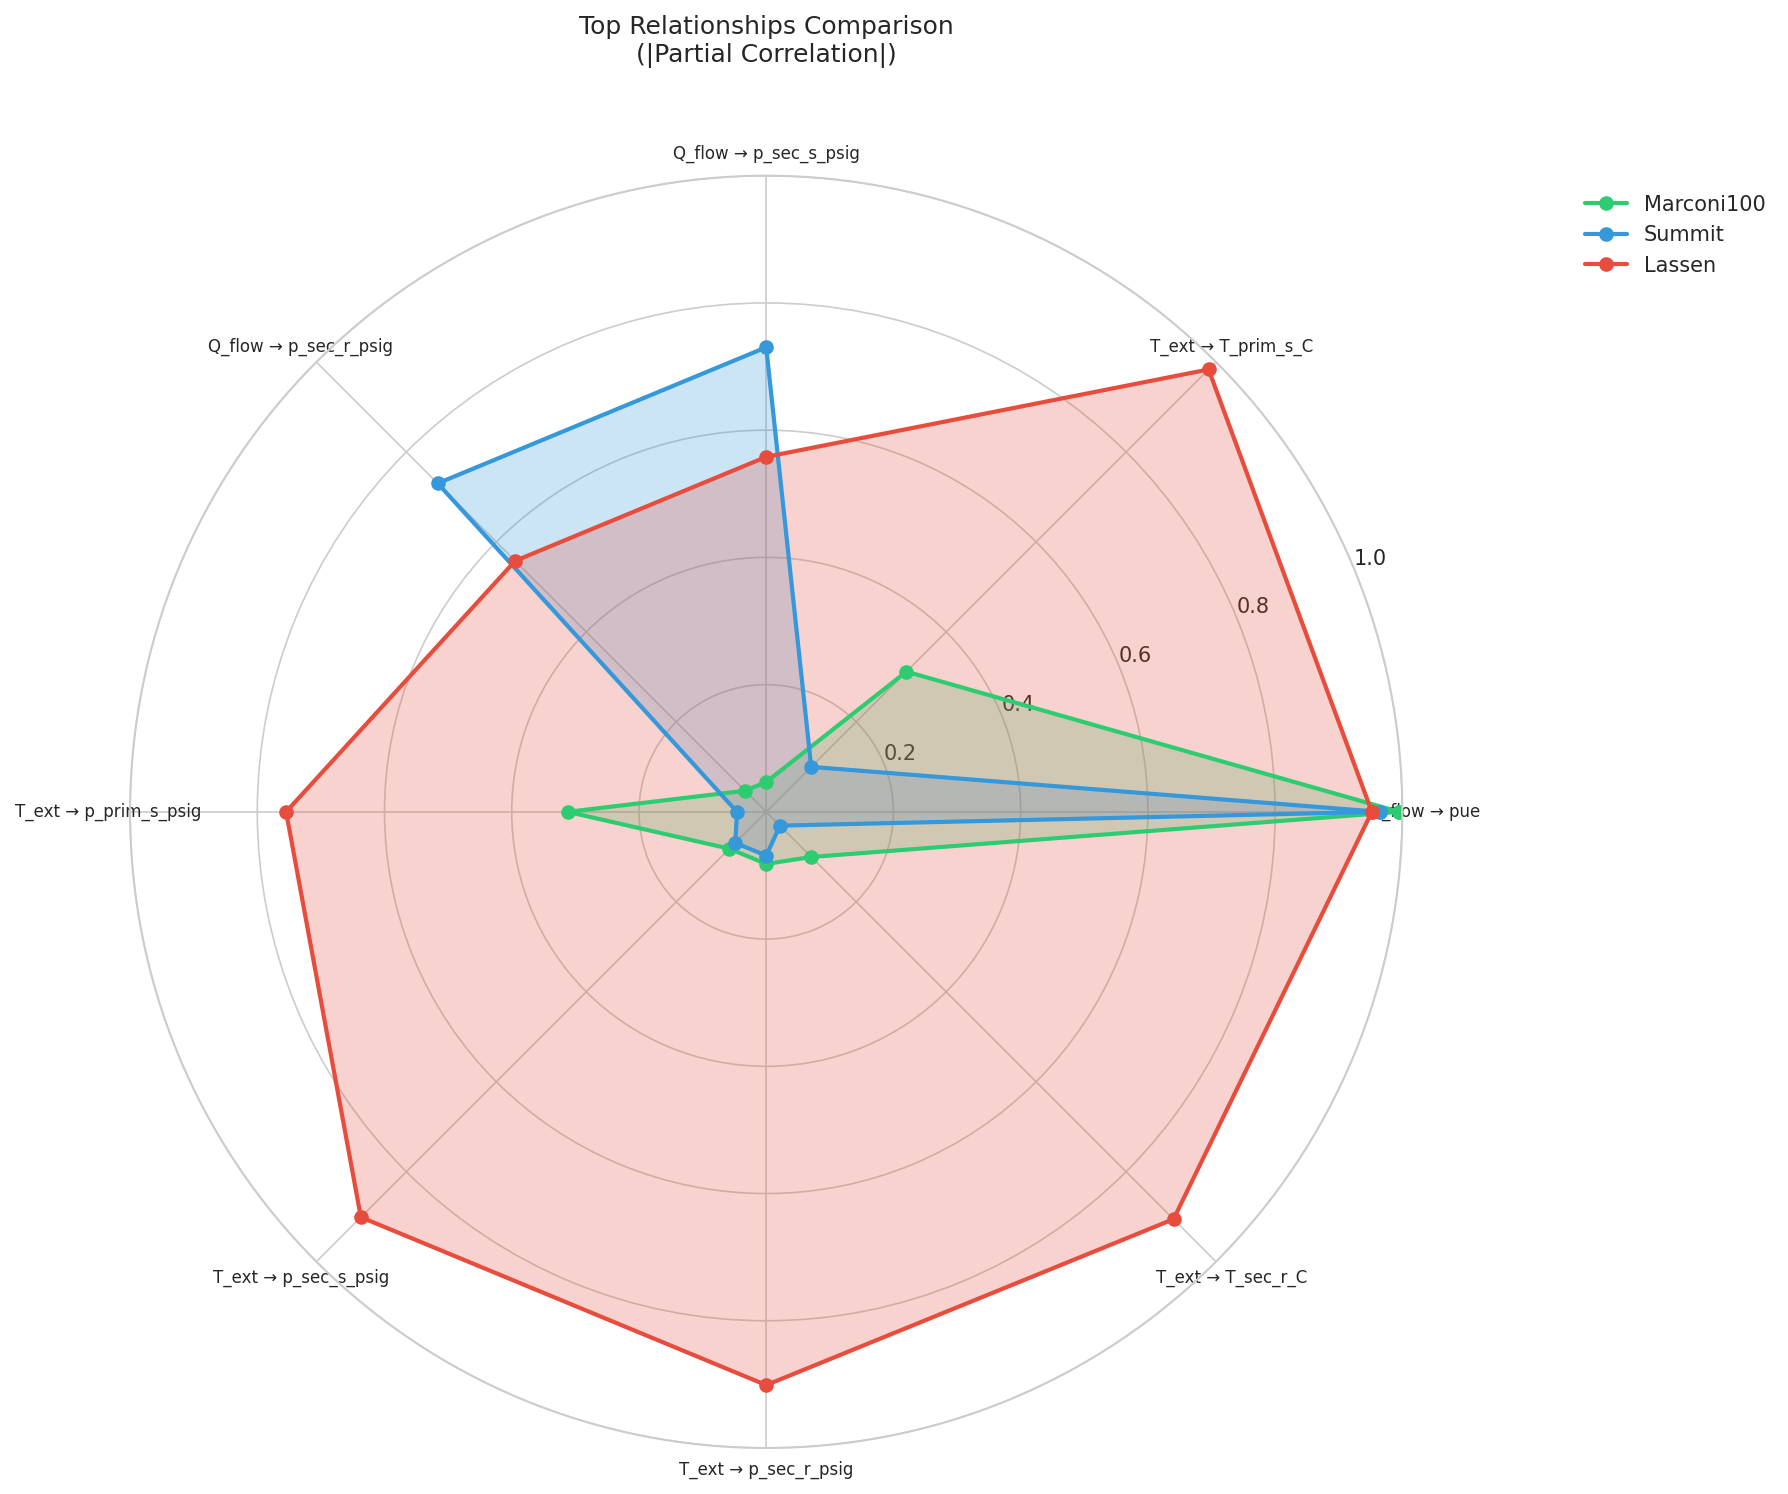

In [21]:
figures = plot_top_relationships_radar(data, save_path='../results/all/')  
plt.show()


## 2. Multiple Regression Analysis

In [13]:
# Multiple Regression Analysis - Setup
regression_analyzer = MultipleRegressionAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    vif_threshold=10.0,
    significance_threshold=0.05,
    standardize=True,
    bootstrap_samples=1000
)

reg_prepared_data = regression_analyzer.prepare_data(data)
print("Data prepared for regression analysis")


2026-01-30 07:20:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - MultipleRegressionAnalyzer initialized for system: summit
2026-01-30 07:20:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - VIF threshold: 10.0, Standardize: True
2026-01-30 07:20:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Preparing data for multiple regression analysis...
2026-01-30 07:20:04 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


Data prepared for regression analysis


In [14]:

# Multiple Regression Analysis - Compute
print("Performing multiple regression analysis...")
regression_df = regression_analyzer.analyze_multiple_regression(reg_prepared_data)

print(f"\nOutputs analyzed: {len(regression_df)}")
print(f"Mean R²: {regression_df['r2'].mean():.3f}")
print(f"Well-explained outputs (R² > 0.7): {(regression_df['r2'] > 0.7).sum()}")

# Display best models
top_models = regression_df.nlargest(5, 'r2')
print("\nTop 5 Best Explained Outputs:")
print(top_models[['output', 'r2', 'adj_r2', 'f_statistic', 'f_pvalue']])


2026-01-30 07:20:04 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Performing multiple regression analysis...
2026-01-30 07:20:04 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Initializing Dask cluster for multiple regression analysis...
2026-01-30 07:20:04 - distributed.scheduler - INFO - State start
2026-01-30 07:20:04 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:38153
2026-01-30 07:20:04 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:35901/status
2026-01-30 07:20:04 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Performing multiple regression analysis...


2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35915'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33853'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33017'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33905'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35263'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34729'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45283'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33893'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35309'
2026-01-30 07:20:04 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33337'
2026-01-30 07:20:04 - distribu


Outputs analyzed: 12
Mean R²: 0.197
Well-explained outputs (R² > 0.7): 1

Top 5 Best Explained Outputs:
            output        r2    adj_r2    f_statistic      f_pvalue
11             pue  0.929688  0.929684  264426.871697  1.110223e-16
10    p_sec_r_psig  0.534313  0.534290   22945.803243  1.110223e-16
9     p_sec_s_psig  0.534311  0.534288   22945.630109  1.110223e-16
1   V_flow_sec_GPM  0.345107  0.345075   10538.650828  1.110223e-16
3       T_prim_s_C  0.011230  0.011180     227.129794  1.110223e-16


2026-01-30 07:36:47 - distributed.scheduler - INFO - Remove client Client-02ebec9e-fdd6-11f0-8357-0a580a221f99
2026-01-30 07:36:47 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:47220; closing.
2026-01-30 07:36:47 - distributed.scheduler - INFO - Remove client Client-02ebec9e-fdd6-11f0-8357-0a580a221f99
2026-01-30 07:36:48 - distributed.scheduler - INFO - Close client connection: Client-02ebec9e-fdd6-11f0-8357-0a580a221f99


In [15]:

# Multiple Regression - Detailed Results
# Extract beta coefficients for a specific output
example_output = KEY_OUTPUTS[0]
output_data = regression_df[regression_df['output'] == example_output].iloc[0]

print(f"\nRegression Model for {example_output}:")
print(f"R² = {output_data['r2']:.4f}")
print(f"Adjusted R² = {output_data['adj_r2']:.4f}")
print(f"F-statistic = {output_data['f_statistic']:.2f} (p = {output_data['f_pvalue']:.4e})")

print("\nBeta Coefficients:")
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    beta = output_data.get(f'beta_{input_var}', np.nan)
    pval = output_data.get(f'pvalue_{input_var}', np.nan)
    vif = output_data.get(f'vif_{input_var}', np.nan)
    print(f"  {input_var}: β = {beta:.4f}, p = {pval:.4e}, VIF = {vif:.2f}")



Regression Model for T_prim_r_C:
R² = 0.0007
Adjusted R² = 0.0006
F-statistic = 13.54 (p = 7.9421e-09)

Beta Coefficients:
  Q_flow: β = -0.0076, p = 5.0238e-02, VIF = 1.00
  T_Air: β = -0.0009, p = 8.2808e-01, VIF = 1.00
  T_ext: β = 0.0249, p = 4.8572e-08, VIF = 1.00


2026-01-30 07:20:15 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting beta coefficient matrix...
2026-01-30 07:20:15 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting significance matrix...
2026-01-30 07:20:15 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing VIF summary...
2026-01-30 07:20:15 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing variance explained summary...
2026-01-30 07:20:15 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating beta coefficient plot...
2026-01-30 07:20:17 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Created beta coefficient plot
2026-01-30 07:20:17 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating 

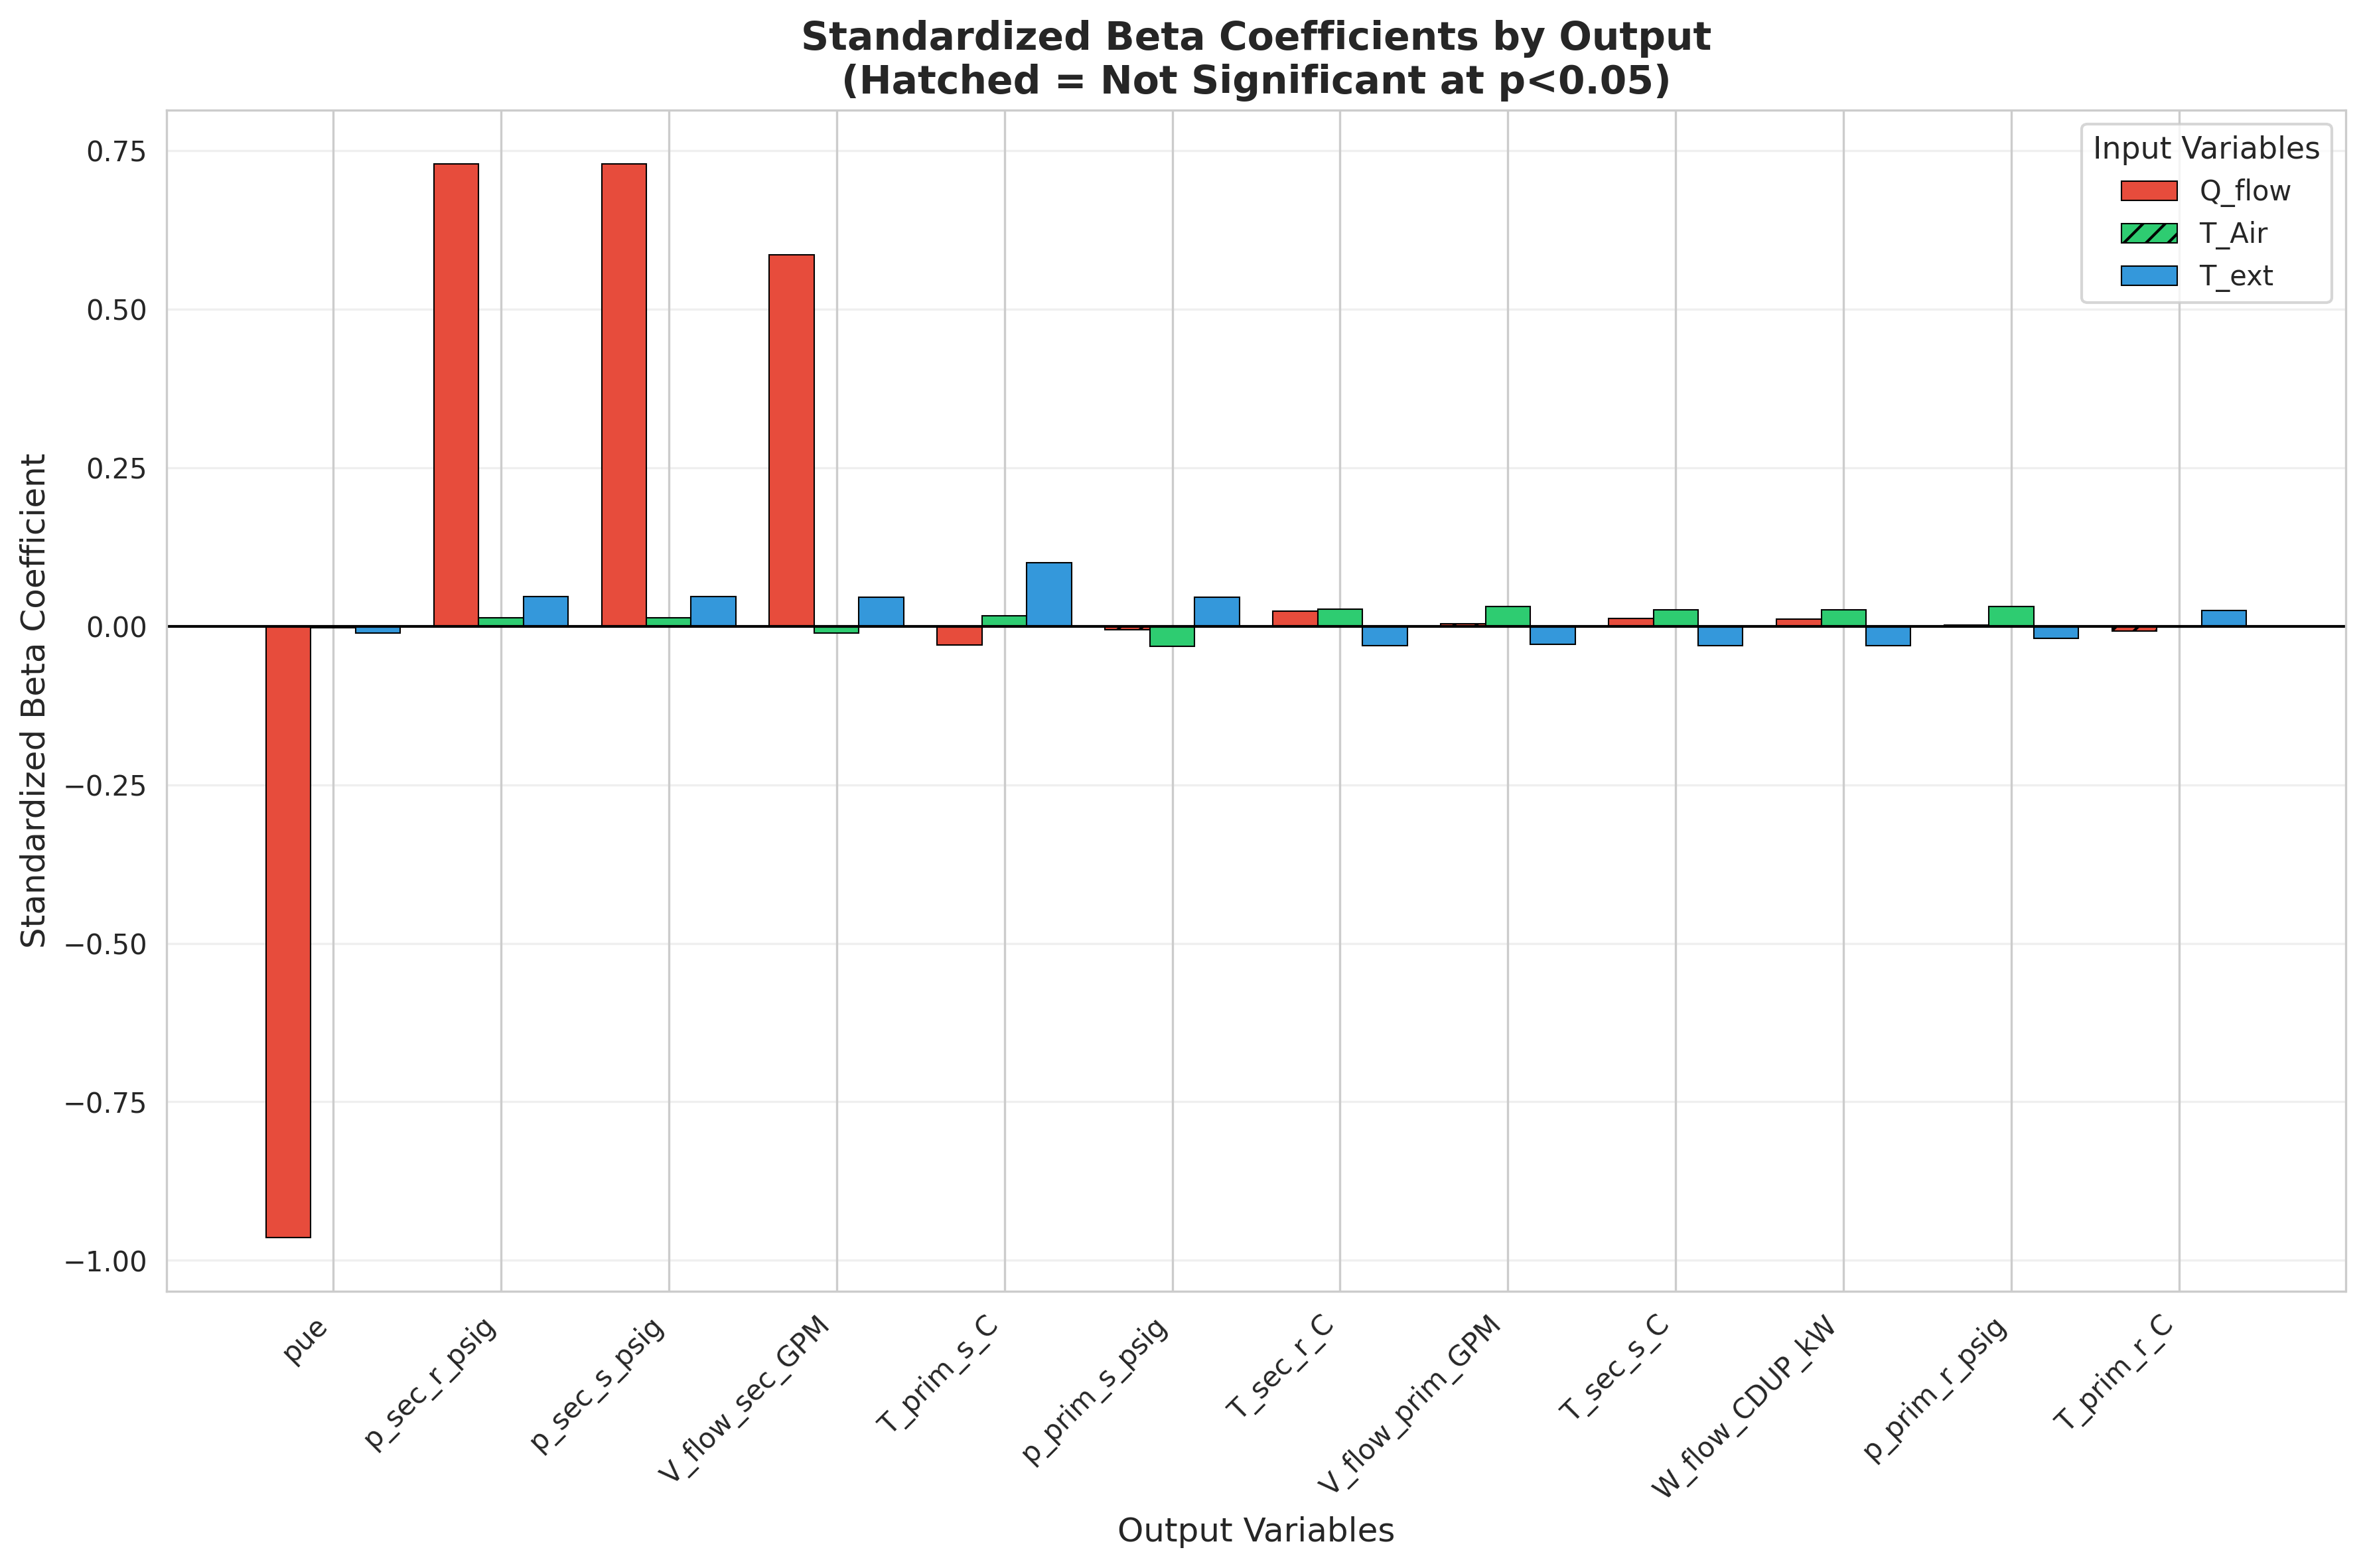

In [16]:
# Multiple Regression - Visualizations
beta_matrix = regression_analyzer.compute_beta_coefficient_matrix(regression_df)
pvalue_matrix = regression_analyzer.compute_significance_matrix(regression_df)
vif_summary = regression_analyzer.compute_vif_summary(regression_df)
variance_df = regression_analyzer.compute_variance_explained(regression_df)

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'regression')
os.makedirs(viz_dir, exist_ok=True)

create_beta_coefficient_plot(regression_df, viz_dir)
create_significance_heatmap(pvalue_matrix, viz_dir)
create_variance_explained_chart(variance_df, viz_dir)
create_vif_plot(vif_summary, viz_dir, threshold=10.0)
create_regression_summary_plot(regression_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'beta_coefficients.png'))


## 3. Lagged Effect Analysis

In [6]:

#  Lagged Effect Analysis - Setup
lagged_analyzer = LaggedEffectAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=MAX_LAG*40,
    min_lag=0,
    lag_step=15,
    cv_folds=5,
    significance_threshold=0.05
)

lag_prepared_data = lagged_analyzer.prepare_data(data)
print(f"Data prepared for lagged analysis. Max lag: {MAX_LAG*40}")


2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - LaggedEffectAnalyzer initialized for system: summit
2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Max lag: 1200, Lag step: 15
2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Preparing data for lagged effect analysis...
2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for lagged analysis. Max lag: 1200


In [7]:

# Lagged Effect Analysis - Compute
print("Analyzing lagged effects (this may take a while)...")
lag_df = lagged_analyzer.analyze_lagged_effects(lag_prepared_data)

print(f"\nRelationships analyzed: {len(lag_df)}")
print(f"Need sequence inputs: {lag_df['needs_sequence_input'].sum()}")
print(f"Average memory length: {lag_df['memory_length'].mean():.1f} lags")

# Display relationships needing sequences
needs_seq = lag_df[lag_df['needs_sequence_input']]
print(f"\nTop relationships requiring sequence inputs:")
print(needs_seq.nlargest(5, 'optimal_lag')[['input', 'output', 'optimal_lag', 'memory_length']])


2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Analyzing lagged effects...
2026-02-06 07:44:53 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Initializing Dask cluster for lagged effect analysis...


Analyzing lagged effects (this may take a while)...


2026-02-06 07:44:53 - distributed.scheduler - INFO - State start
2026-02-06 07:44:53 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:43257
2026-02-06 07:44:53 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-02-06 07:44:53 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39489'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35515'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33413'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38205'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46175'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42757'
2026-02-06 07:44:54 - distributed.nanny - INFO -         Start Nanny at:


Relationships analyzed: 36
Need sequence inputs: 12
Average memory length: 643.8 lags

Top relationships requiring sequence inputs:
    input          output  optimal_lag  memory_length
28  T_ext      T_prim_r_C         1200           1200
26  T_ext  W_flow_CDUP_kW         1200           1200
29  T_ext       T_sec_s_C         1200           1200
30  T_ext       T_sec_r_C         1200           1200
32  T_ext   p_prim_r_psig          720           1200


2026-02-06 09:42:18 - distributed.scheduler - INFO - Remove client Client-a37f2c41-0359-11f1-805a-0a580a2216cd
2026-02-06 09:42:18 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:41506; closing.
2026-02-06 09:42:18 - distributed.scheduler - INFO - Remove client Client-a37f2c41-0359-11f1-805a-0a580a2216cd
2026-02-06 09:42:18 - distributed.scheduler - INFO - Close client connection: Client-a37f2c41-0359-11f1-805a-0a580a2216cd


In [8]:
# Lagged Effect Analysis - Summaries
cumulative_df = lagged_analyzer.compute_cumulative_effects(lag_df)
memory_summary = lagged_analyzer.get_memory_length_summary(lag_df)

print("Memory Length Summary:")
print(memory_summary)

print("\nCumulative Effects (sample):")
print(cumulative_df.head(10))


2026-02-06 08:35:32 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing cumulative effects...
2026-02-06 08:35:32 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing memory length summary...


Memory Length Summary:
    input  mean_memory_length  max_memory_length  mean_optimal_lag  \
0  Q_flow              195.00               1200             16.25   
1   T_Air              536.25               1200             13.75   
2   T_ext             1200.00               1200            723.75   

   pct_needs_sequence  mean_r2_improvement  
0            8.333333             0.027291  
1            0.000000             0.011172  
2           91.666667             0.122421  

Cumulative Effects (sample):
    input           output  lag  coefficient  cumulative_effect
0  Q_flow  V_flow_prim_GPM    0    -0.839601          -0.839601
1  Q_flow  V_flow_prim_GPM   15     1.100579           0.260979
2  Q_flow  V_flow_prim_GPM   30    -0.170142           0.090837
3  Q_flow  V_flow_prim_GPM   45     0.599159           0.689996
4  Q_flow  V_flow_prim_GPM   60    -1.968683          -1.278687
5  Q_flow  V_flow_prim_GPM   75     1.980540           0.701853
6  Q_flow  V_flow_prim_GPM   90    -0.

2026-02-06 08:35:32 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating lag coefficient plots in parallel...
2026-02-06 08:35:34 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created 36/36 lag coefficient plots
2026-02-06 08:35:34 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating lag heatmap...
2026-02-06 08:35:36 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created lag heatmap
2026-02-06 08:35:36 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating memory length plot...
2026-02-06 08:35:37 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created memory length plot
2026-02-06 08:35:37 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating cumulative effec

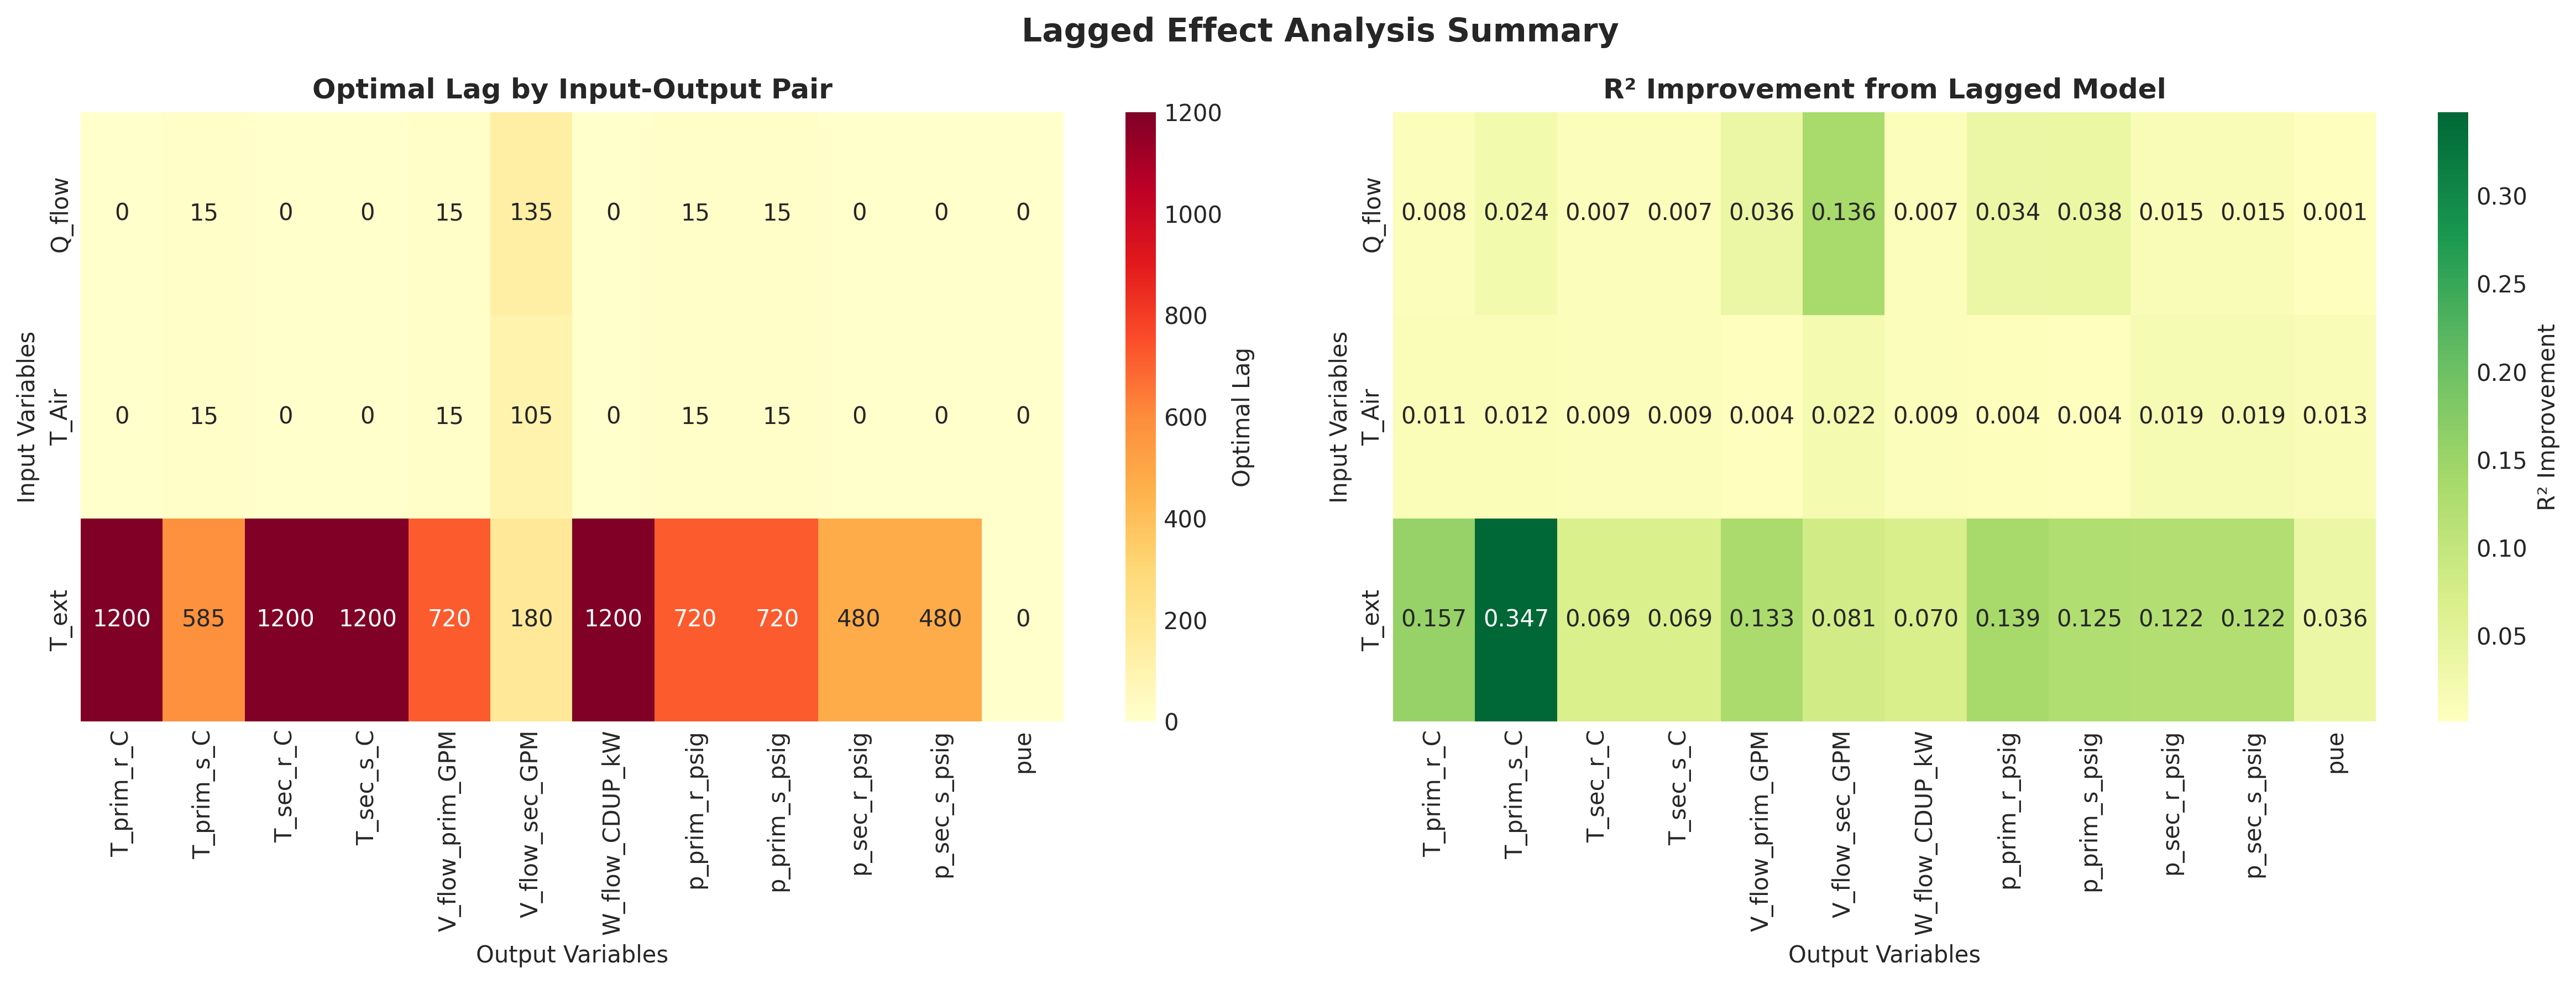

In [9]:

#  Lagged Effect - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'lagged_effects')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(lagged_analyzer, '_full_lag_results'):
    create_lag_coefficient_plots(
        lagged_analyzer._full_lag_results,
        viz_dir,
        n_workers=N_WORKERS
    )

create_lag_heatmap(lag_df, viz_dir)
create_memory_length_plot(memory_summary, viz_dir)
create_cumulative_effect_summary(cumulative_df, viz_dir)
create_lag_analysis_summary(lag_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'lag_heatmap.png'))


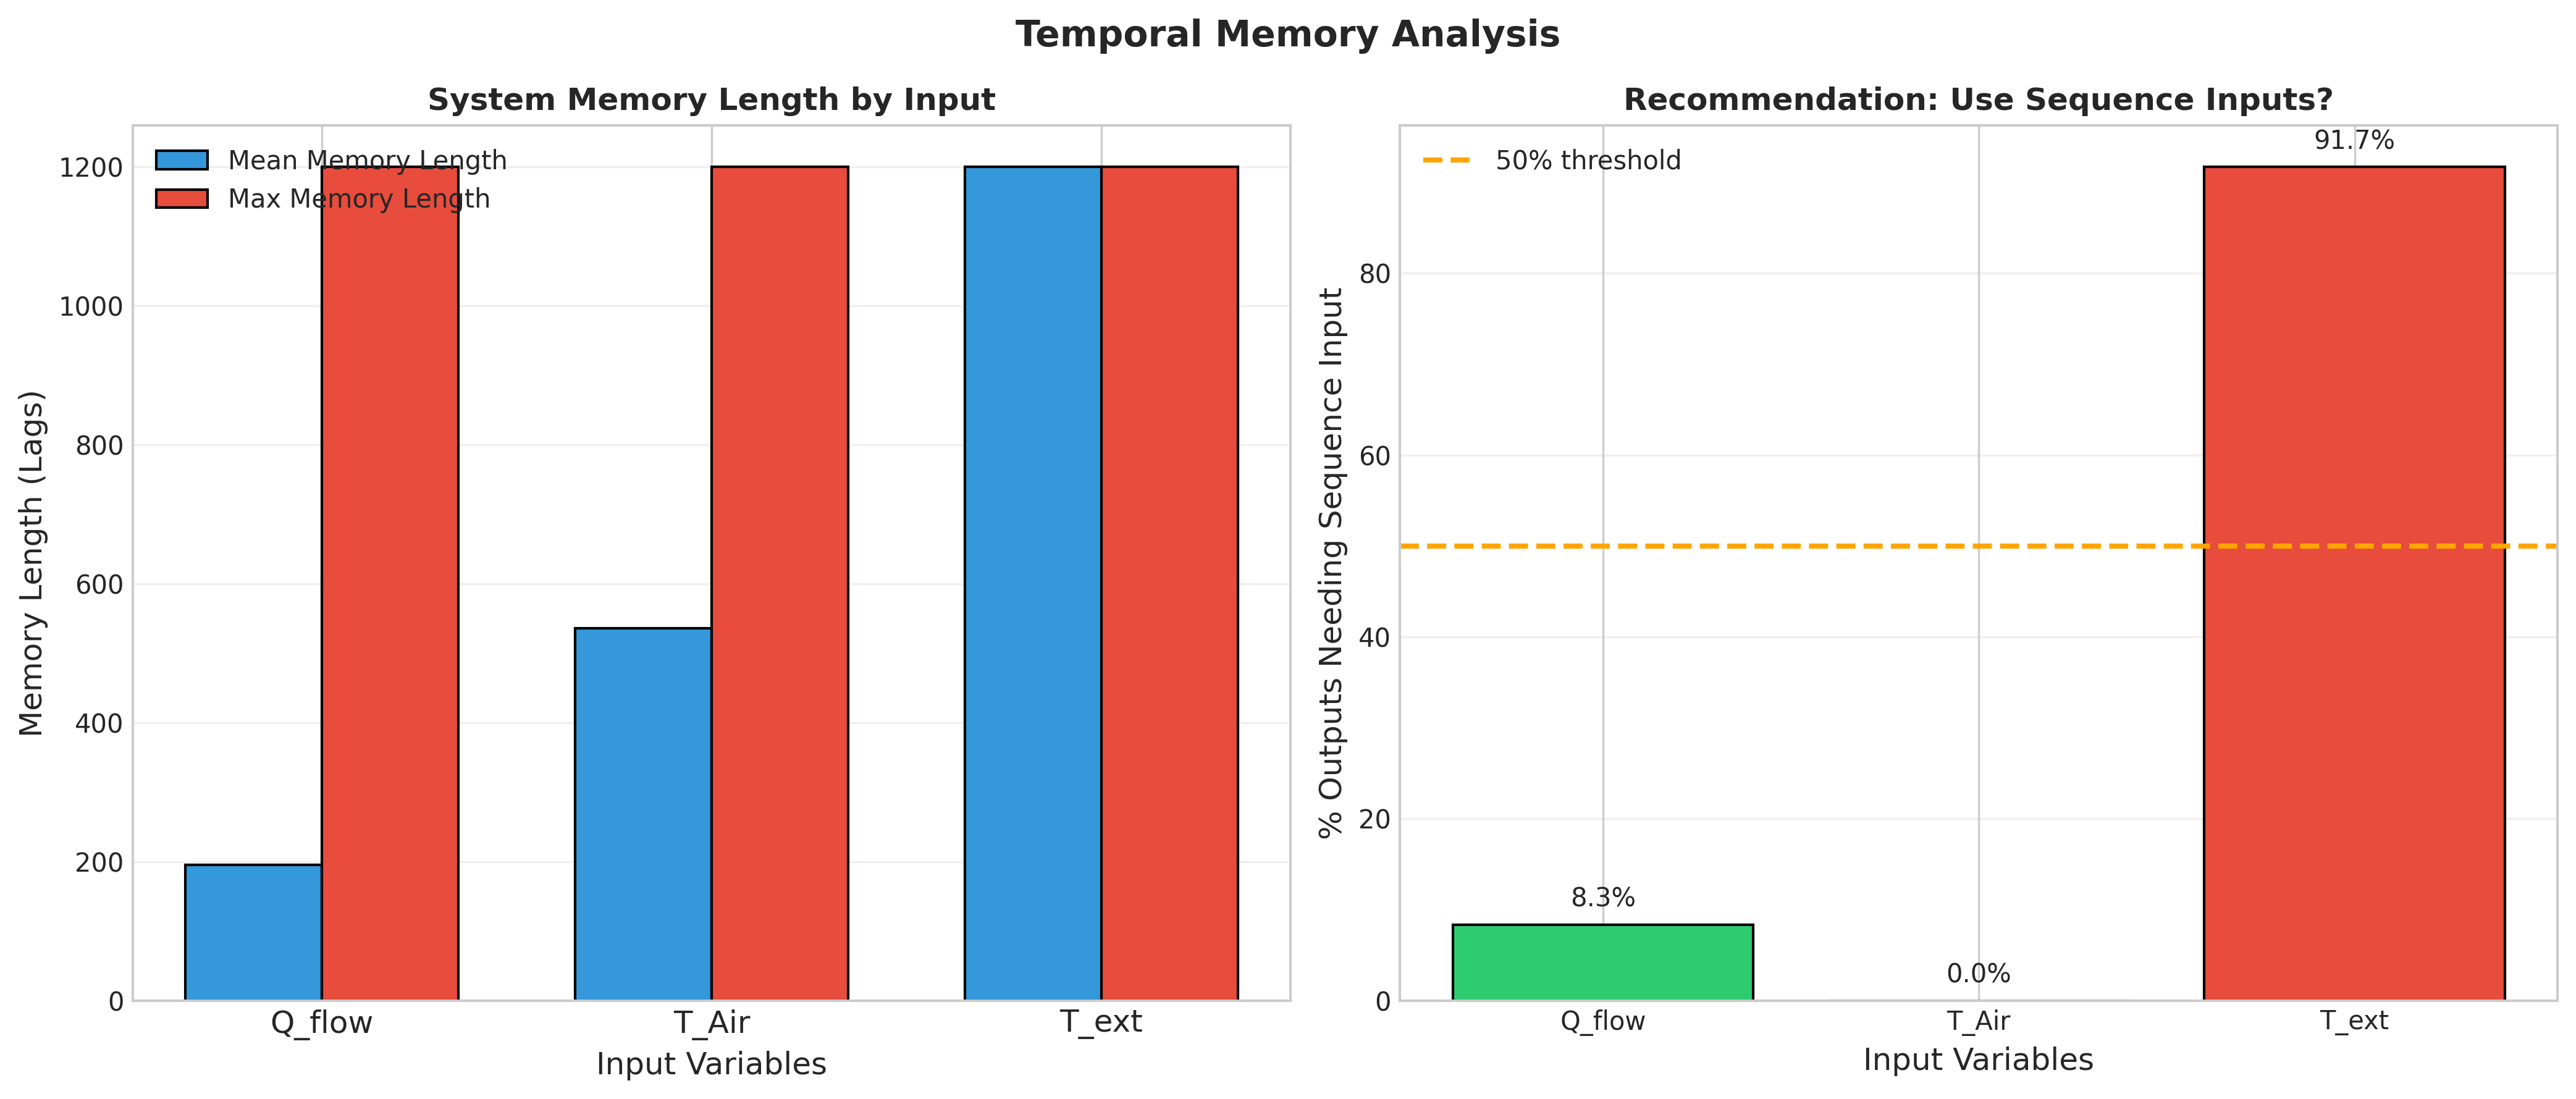

In [10]:
Image(filename=os.path.join(viz_dir, 'memory_length.png'))


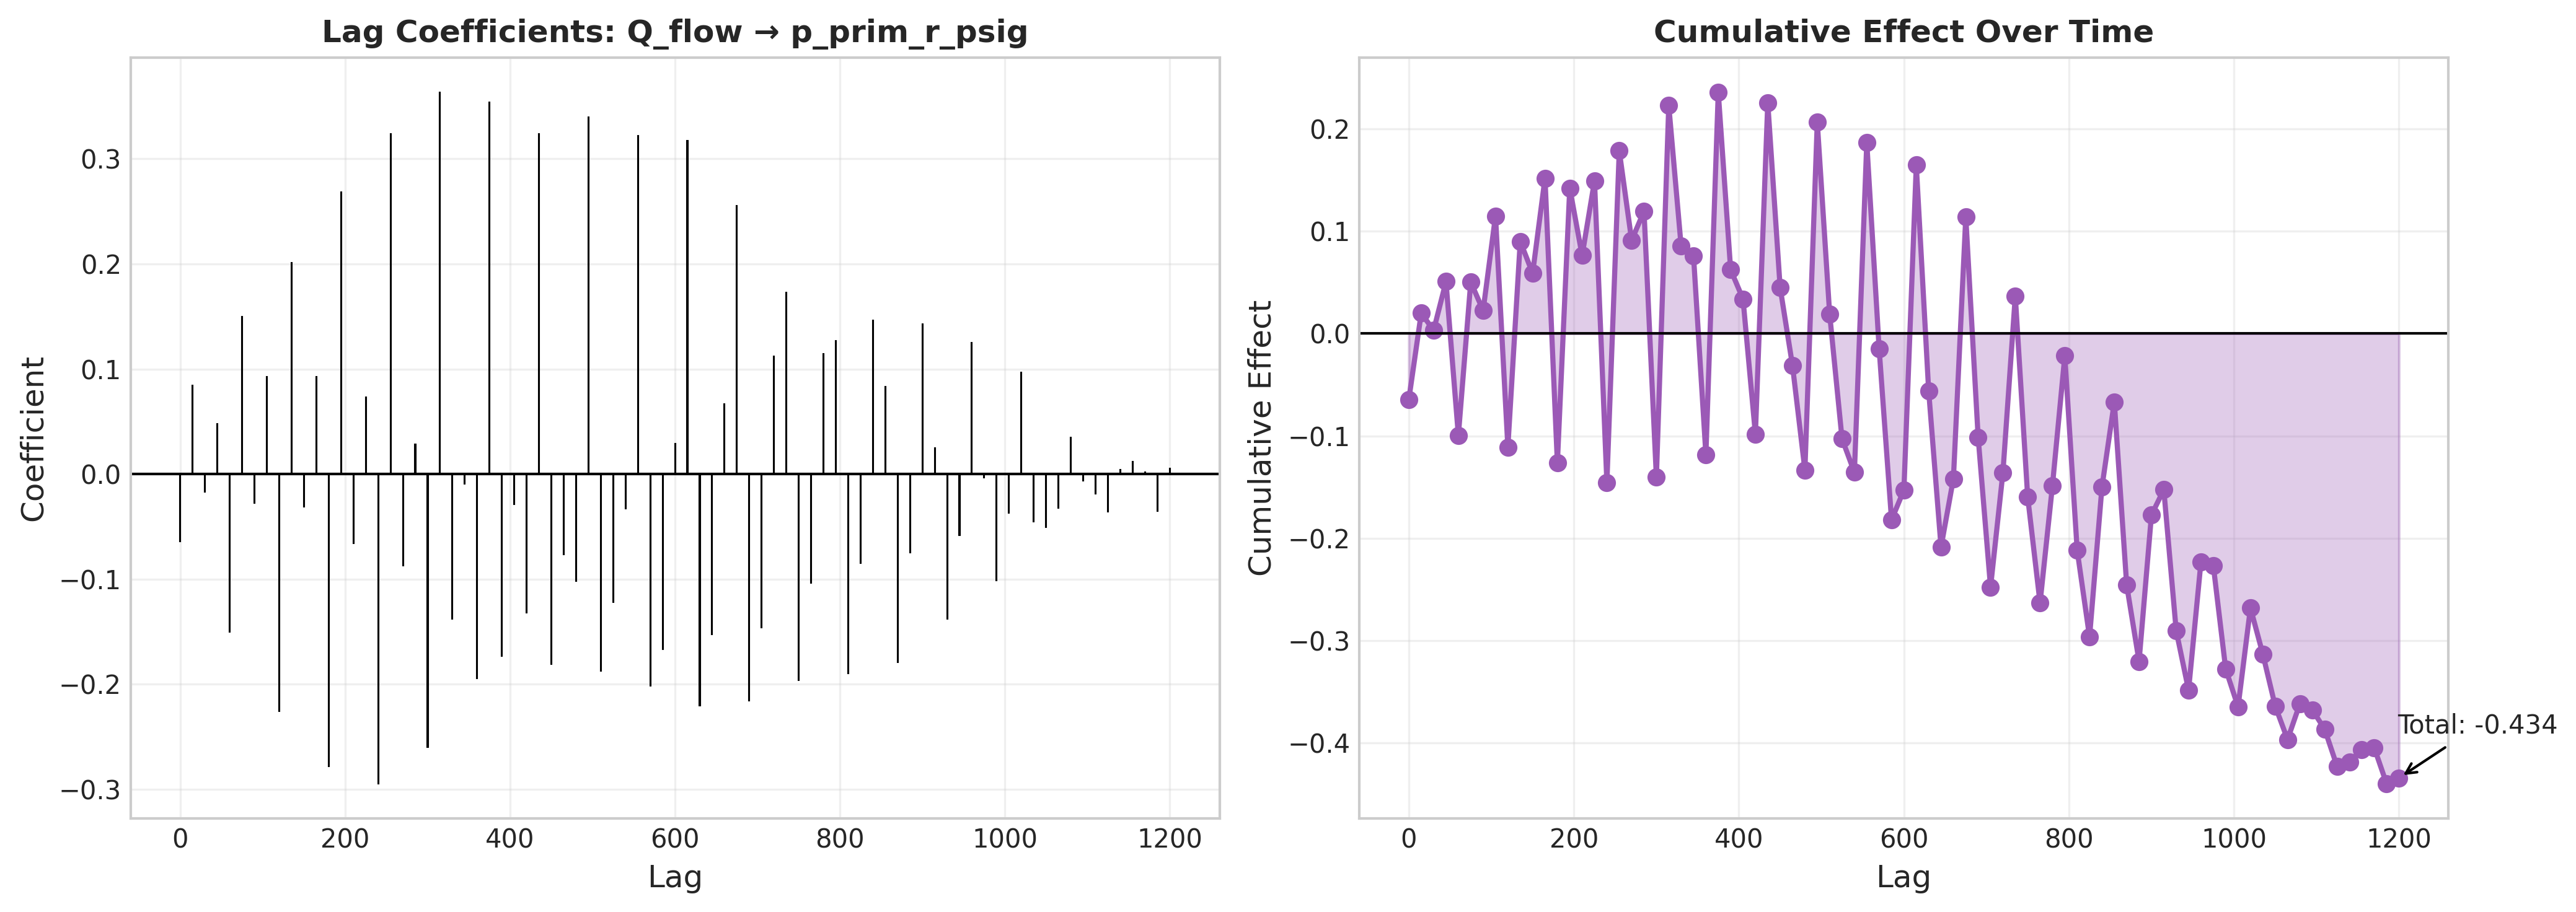

In [11]:
Image(filename=os.path.join(viz_dir, 'lag_coefficients_Q_flow_p_prim_r_psig.png'))


## 4. Autocorrelation Analysis

In [6]:
#  Autocorrelation Analysis - Setup
autocorr_analyzer = AutocorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=1500,
    confidence_level=0.95,
    compute_pacf=True,
    compute_ccf=True
)

autocorr_prepared_data = autocorr_analyzer.prepare_data(data)
print("Data prepared for autocorrelation analysis")


2026-02-05 20:30:58 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - AutocorrelationAnalyzer initialized for system: summit
2026-02-05 20:30:58 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Max lag: 1500, Confidence level: 0.95
2026-02-05 20:30:58 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Preparing data for autocorrelation analysis...
2026-02-05 20:30:59 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for autocorrelation analysis


In [ ]:
#   Autocorrelation Analysis - ACF/PACF
print("Computing ACF and PACF...")
input_acf_df, output_acf_df = autocorr_analyzer.analyze_autocorrelation(autocorr_prepared_data)

print(f"\nInput ACF results: {len(input_acf_df)} variables")
print(f"Output ACF results: {len(output_acf_df)} variables")


In [ ]:
input_acf_df

In [ ]:
output_acf_df

In [ ]:

# Autocorrelation Analysis - Cross-Correlation
print("Computing cross-correlations...")
ccf_df = autocorr_analyzer.analyze_cross_correlation(autocorr_prepared_data)

print(f"\nCross-correlations computed: {len(ccf_df)}")

# Show strongest cross-correlations
ccf_df['abs_max_ccf'] = ccf_df['peak_ccf'].abs()
top_ccf = ccf_df.nlargest(10, 'abs_max_ccf')
print("\nTop 10 Cross-Correlations:")
print(top_ccf[['input', 'output', 'peak_ccf', 'peak_lag', 'n_significant_lags']])


In [ ]:

# Autocorrelation - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'autocorrelation')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(autocorr_analyzer, '_acf_results'):
    create_acf_plots(autocorr_analyzer._acf_results, viz_dir, n_workers=N_WORKERS)

if hasattr(autocorr_analyzer, '_ccf_results'):
    create_ccf_plots(autocorr_analyzer._ccf_results, viz_dir, n_workers=N_WORKERS)

create_persistence_summary(input_acf_df, output_acf_df, viz_dir)
create_ccf_heatmap(ccf_df, viz_dir)
create_temporal_recommendations_plot(recommendations_df, viz_dir, )

Image(filename=os.path.join(viz_dir, 'persistence_summary.png'))


2026-02-05 20:31:42 - distributed.nanny - INFO - Worker process 16055 was killed by signal 9
2026-02-05 20:31:42 - distributed.nanny - INFO - Worker process 16095 was killed by signal 9
2026-02-05 20:31:42 - distributed.nanny - INFO - Worker process 16111 was killed by signal 9


In [31]:
partial_df

,input,output,pearson_corr,pearson_pvalue,partial_corr,partial_pvalue,corr_difference,is_direct_effect
11,Q_flow,pue,-0.964135,0.000000e+00,-0.964199,0.000000e+00,-0.000065,True
10,Q_flow,p_sec_r_psig,0.729299,0.000000e+00,0.730241,0.000000e+00,-0.000942,True
9,Q_flow,p_sec_s_psig,0.729298,0.000000e+00,0.730240,0.000000e+00,-0.000942,True
1,Q_flow,V_flow_sec_GPM,0.585580,0.000000e+00,0.586230,0.000000e+00,-0.000650,True
27,T_ext,T_prim_s_C,0.100324,5.196573e-134,0.100049,2.803506e-133,0.000275,True
34,T_ext,p_sec_r_psig,0.046446,5.093421e-30,0.068898,4.811983e-64,-0.022452,False
33,T_ext,p_sec_s_psig,0.046441,5.169282e-30,0.068891,4.972695e-64,-0.022450,False
25,T_ext,V_flow_sec_GPM,0.044856,4.138650e-28,0.056500,1.269634e-43,-0.011644,False
31,T_ext,p_prim_s_psig,0.045320,1.164222e-28,0.045894,2.392968e-29,-0.000573,False
35,T_ext,pue,-0.010003,1.427624e-02,-0.042179,4.843654e-25,-0.032176,False


In [33]:

# Integrated Summary - Input Importance
print("="*60)
print("MULTIVARIATE INPUT IMPORTANCE")
print("="*60)

# Aggregate importance across analyses
importance_summary = {}

# From regression beta coefficients
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    beta_cols = [col for col in regression_df.columns if col.startswith(f'beta_{input_var}')]
    if beta_cols:
        importance_summary[input_var] = {
            'mean_beta': regression_df[beta_cols[0]].abs().mean(),
            'significant_effects': (regression_df[f'pvalue_{input_var}'] < 0.05).sum()
        }

print("\nRegression-based Importance:")
for var, metrics in importance_summary.items():
    print(f"  {var}:")
    print(f"    Mean |β|: {metrics['mean_beta']:.4f}")
    print(f"    Significant effects: {metrics['significant_effects']}")


MULTIVARIATE INPUT IMPORTANCE

Regression-based Importance:
  Q_flow:
    Mean |β|: 0.2587
    Significant effects: 8
  T_Air:
    Mean |β|: 0.0192
    Significant effects: 10
  T_ext:
    Mean |β|: 0.0384
    Significant effects: 12


In [ ]:

#  Export Results Summary
# Save all results
partial_df.to_csv(os.path.join(OUTPUT_DIR, 'partial_correlations.csv'), index=False)
regression_df.to_csv(os.path.join(OUTPUT_DIR, 'multiple_regression.csv'), index=False)
lag_df.to_csv(os.path.join(OUTPUT_DIR, 'lagged_effects.csv'), index=False)
input_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'input_acf.csv'), index=False)
output_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'output_acf.csv'), index=False)
ccf_df.to_csv(os.path.join(OUTPUT_DIR, 'cross_correlations.csv'), index=False)
recommendations_df.to_csv(os.path.join(OUTPUT_DIR, 'temporal_recommendations.csv'), index=False)

print(f"All results saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - partial_correlations.csv")
print("  - multiple_regression.csv")
print("  - lagged_effects.csv")
print("  - input_acf.csv, output_acf.csv")
print("  - cross_correlations.csv")
print("  - temporal_recommendations.csv")
print("  - visualizations/ (multiple subfolders)")

#  Cleanup
# Close Dask clients
partial_analyzer._close_dask_client()
regression_analyzer._close_dask_client()
lagged_analyzer._close_dask_client()
autocorr_analyzer._close_dask_client()

print("Analysis complete! Dask clients closed.")